---
# CALINET GLM

In [1]:
%reload_ext autoreload
%autoreload 2

In [31]:
import os
import pandas as pd
from pathlib import Path

from lazyfmri import glm
from calinet import utils
from lazyfmri import plotting
import calinet.core.io as cio

In [79]:
%matplotlib inline
subj_path = Path(r'D:\teaching\2026\EMHFC_PsPM\PsPM_course_EMHFC2026\BIDS_Example\sub-Synth01')
phys_file = list(subj_path.glob("**/*physio.tsv.gz"))[0]
df_physio = cio.read_physio_tsv_headerless(phys_file)
df_physio.head()

,timestamp,scr
0,0.00,0.043100
1,0.01,0.008969
2,0.02,0.020400
3,0.03,0.043442
4,0.04,-0.006226


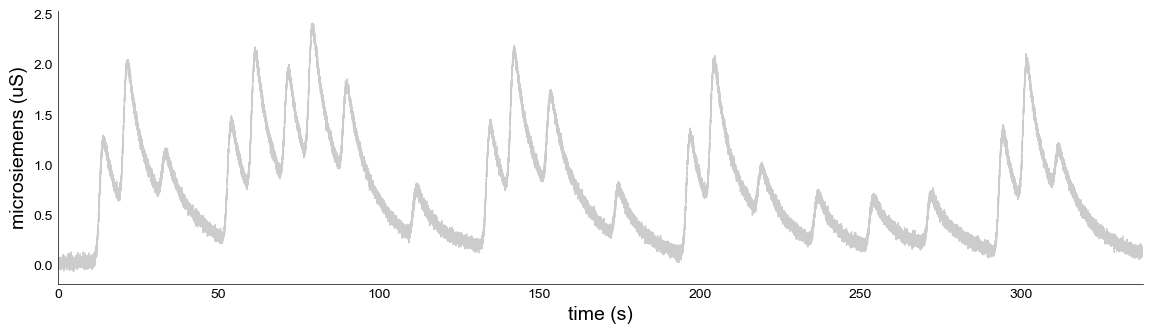

In [236]:
pl = plotting.LazyLine(
    df_physio['scr'].to_numpy(),
    xx=df_physio['timestamp'].to_numpy(),
    color='#cccccc',
    linewidth=0.5,
    figsize=(14, 3.54),
    fontname="Arial",
    x_label="time (s)",
    y_label="microsiemens (uS)",
    save_as=r'C:\Users\Bach\Downloads\01_tc_basis.svg'
)


In [81]:
event_file = list(subj_path.glob("**/*events.tsv"))[0]
df_event = pd.read_csv(event_file, delimiter='\t')
df_event = df_event[~df_event['event_type'].str.contains("USp")]
print(df_event['event_type'].unique())
df_event.head()

['CSpr' 'CSm' 'CSpu']


,onset,duration,event_type,stimulus_name,task_name
0,10.000,8.0,CSpr,diamond,acquisition
2,29.504,8.0,CSm,square,acquisition
3,49.856,8.0,CSpr,diamond,acquisition
5,67.698,8.0,CSpr,diamond,acquisition
7,85.887,8.0,CSpu,diamond,acquisition


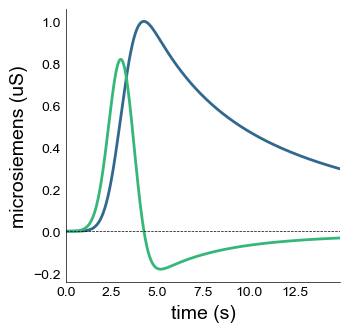

In [273]:
from calinet.imports.pspm import pspm_bf_scrf

bs, time = pspm_bf_scrf([1/100, 1])
plotting.LazyLine(
    [i[:1500] for i in list(bs.T)],
    xx=time[:1500],
    figsize=(3.54, 3.54),
    # color=["#cccccc", "r"],
    line_width=2,
    add_hline=0,
    fontname="Arial",
    x_label="time (s)",
    y_label="microsiemens (uS)",
    # save_as=r'C:\Users\Bach\Downloads\03_tc_rfs.svg'
)

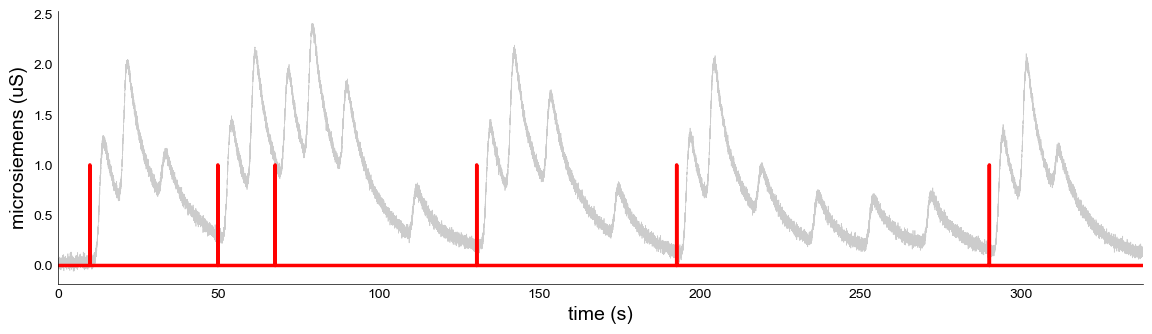

In [264]:
dict_regressors = glm.make_stimulus_vector(
    df_event,
    scan_length=df_physio.shape[0], 
    osf=1,
    TR=1/100,
    type='event'
)

pl = plotting.LazyLine(
    [
        df_physio['scr'].to_numpy(),
        dict_regressors['CSpr']
    ],
    xx=df_physio['timestamp'].to_numpy(),
    color=['#cccccc', 'r'],
    line_width=[0.5, 2.5],
    figsize=(14, 3.54),
    fontname="Arial",
    x_label="time (s)",
    y_label="microsiemens (uS)",
    save_as=r'C:\Users\Bach\Downloads\02_tc_onsets.svg'
)

In [265]:
RF = glm.define_hrf(
    hrf_pars=bs.T,
    TR=1/100,
    osf=1
)

dict_regr_conv = glm.convolve_hrf(
    RF,
    dict_regressors,
    TR=1/100,
    osf=1,
    make_figure=False
)

dict_regr_conv

{'CSm': array([[ 0.        ,  0.        ],
        [ 0.        ,  0.        ],
        [ 0.        ,  0.        ],
        ...,
        [ 0.10345081, -0.00949832],
        [ 0.10337729, -0.00949147],
        [ 0.10330382, -0.00948463]]),
 'CSpr': array([[ 0.        ,  0.        ],
        [ 0.        ,  0.        ],
        [ 0.        ,  0.        ],
        ...,
        [ 0.0276387 , -0.00252746],
        [ 0.02761913, -0.00252567],
        [ 0.02759959, -0.00252388]]),
 'CSpu': array([[0., 0.],
        [0., 0.],
        [0., 0.],
        ...,
        [0., 0.],
        [0., 0.],
        [0., 0.]])}

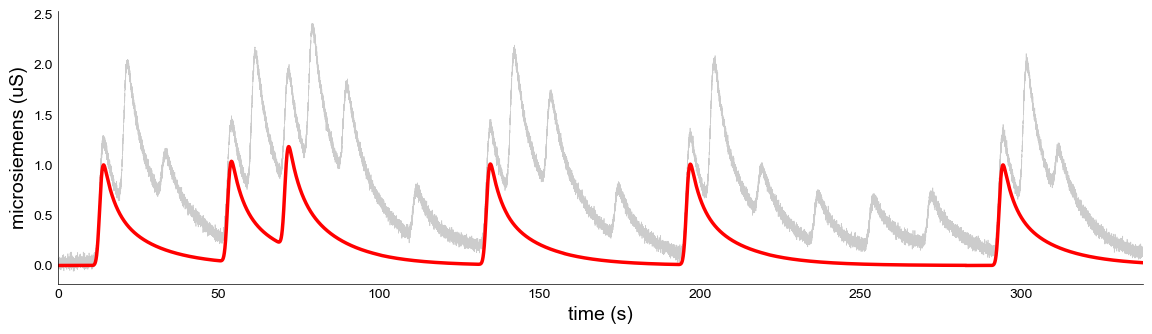

In [266]:
pl = plotting.LazyLine(
    [
        df_physio['scr'].to_numpy(),
        dict_regr_conv['CSpr'][:,0]
    ],
    xx=df_physio['timestamp'].to_numpy(),
    color=['#cccccc', 'r'],
    line_width=[0.5, 2.5],
    figsize=(14, 3.54),
    fontname="Arial",
    x_label="time (s)",
    y_label="microsiemens (uS)",
    save_as=r'C:\Users\Bach\Downloads\04_tc_convolved.svg'
)

(<Axes: label='conditions', ylabel='scan number'>,
 <lazyfmri.plotting.Defaults at 0x1f5878c9d60>)

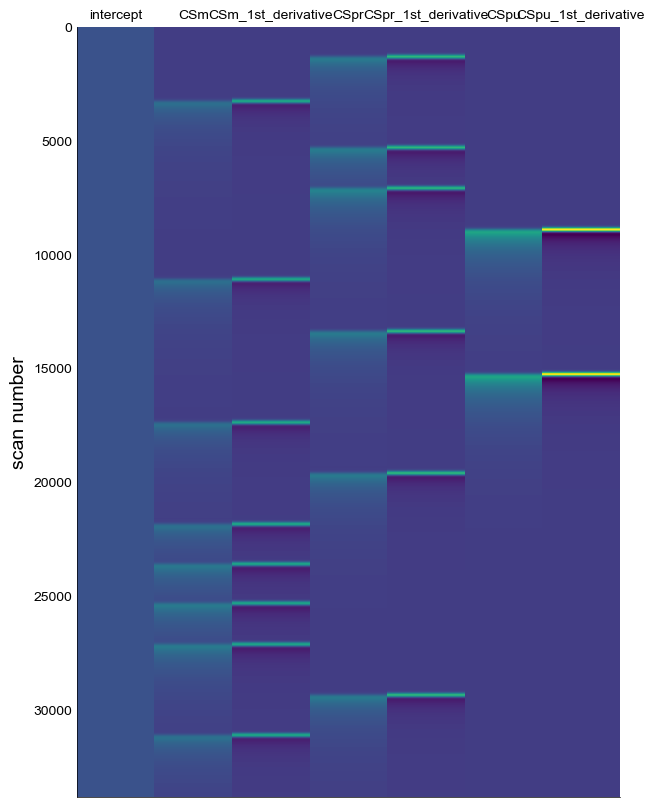

In [268]:
import matplotlib.pyplot as plt
from nilearn.plotting import plot_design_matrix
design = glm.first_level_matrix(
    dict_regr_conv,
    add_intercept=True
)

cols = list(design.columns)
fig, axs = plt.subplots(figsize=(len(cols), 10))
plot_design_matrix(design, axes=axs)
plotting.conform_ax_to_obj(axs, fontname="Arial")

In [329]:
from calinet.imports.pspm import butter_filter_array_uni
import numpy as np

# PsPM SCR defaults
fs_high = 100          # original sampling rate, Hz
down = 10             # PsPM default downsampling factor
fs_low = fs_high / down

lp_freq = 5.0         # PsPM default low-pass cutoff, Hz
hp_freq = 0.05        # PsPM default high-pass cutoff, Hz
filter_order = 1      # PsPM default order

# 1. Low-pass before downsampling
X_lp = butter_filter_array_uni(
    design.values,
    fs=fs_high,
    cutoff_hz=lp_freq,
    btype="low",
    order=filter_order,
)

y_lp = butter_filter_array_uni(
    df_physio["scr"].to_numpy(),
    fs=fs_high,
    cutoff_hz=lp_freq,
    btype="low",
    order=filter_order,
)

# 2. Downsample
X_ds = X_lp[::down]
y_ds = y_lp[::down]

# 3. High-pass after downsampling
#    Do not high-pass the intercept column
cols = list(design.columns)
non_intercept = np.array([c != "intercept" for c in cols])

X_ds_hp = X_ds.copy()
X_ds_hp[:, non_intercept] = butter_filter_array_uni(
    X_ds_hp[:, non_intercept],
    fs=fs_low,
    cutoff_hz=hp_freq,
    btype="high",
    order=filter_order,
)

y_ds_hp = butter_filter_array_uni(
    y_ds,
    fs=fs_low,
    cutoff_hz=hp_freq,
    btype="high",
    order=filter_order,
)

# 4. Ensure GLM data is time x voxels
y_ds_hp = np.asarray(y_ds_hp)

X_ds_hp.shape, y_ds_hp.shape

((3380, 7), (3380,))

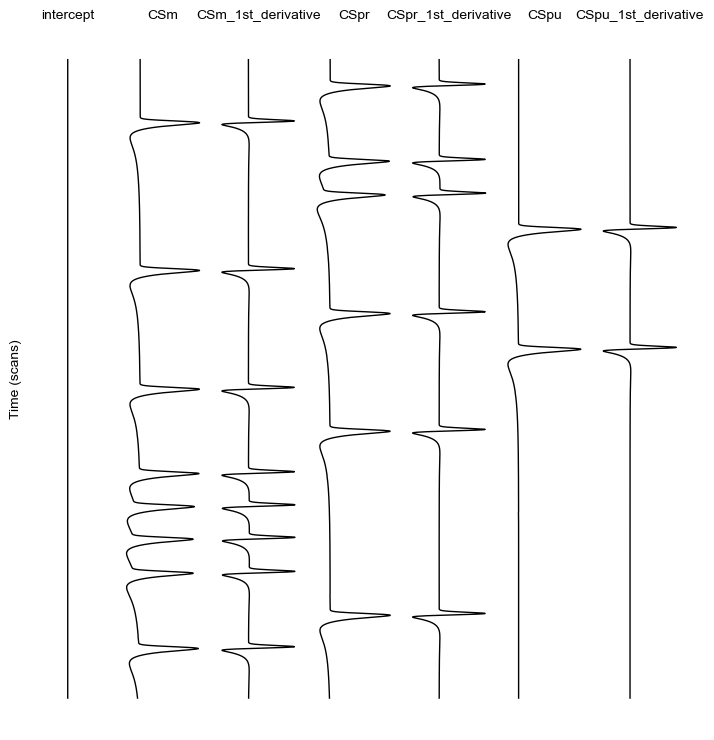

In [382]:
import matplotlib.pyplot as plt
import numpy as np

time = np.arange(len(y_ds_hp))  # or frame_times
cols = design.columns

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(cols),
    figsize=(1 * len(cols), 7.5),
    sharey=True
)

# Handle single column case
if len(cols) == 1:
    axes = [axes]

for i, col in enumerate(cols):
    axes[i].plot(X_ds_hp[:, i], time, color="black", linewidth=1)

    axes[i].set_title(col, fontsize=10)
    axes[i].set_xticks([])

    # Hide all spines except left (optional styling)
    axes[i].spines[['top', 'right', 'bottom']].set_visible(False)

    # if i != 0:
    axes[i].set_yticks([])
    axes[i].set_ylabel("")
    axes[i].spines['left'].set_visible(False)

# Invert y-axis so time goes top → bottom (like matrix)
axes[0].invert_yaxis()
axes[0].set_ylabel("Time (scans)")

plt.tight_layout()
plt.show()

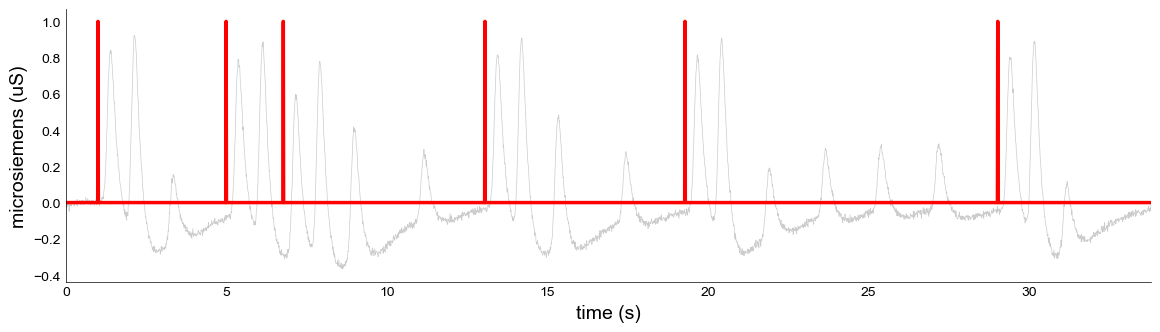

In [358]:
dict_regr_ds = glm.make_stimulus_vector(
    df_event,
    scan_length=y_ds_hp.shape[0], 
    osf=1,
    TR=1/10,
    type='event'
)

pl = plotting.LazyLine(
    [
        y_ds_hp,
        dict_regr_ds['CSpr']
    ],
    xx=np.arange(0, y_ds_hp.shape[0])/100,
    color=['#cccccc', 'r'],
    line_width=[0.5, 2.5],
    figsize=(14, 3.54),
    fontname="Arial",
    x_label="time (s)",
    y_label="microsiemens (uS)",
    save_as=r'C:\Users\Bach\Downloads\02_tc_onsets.svg'
)

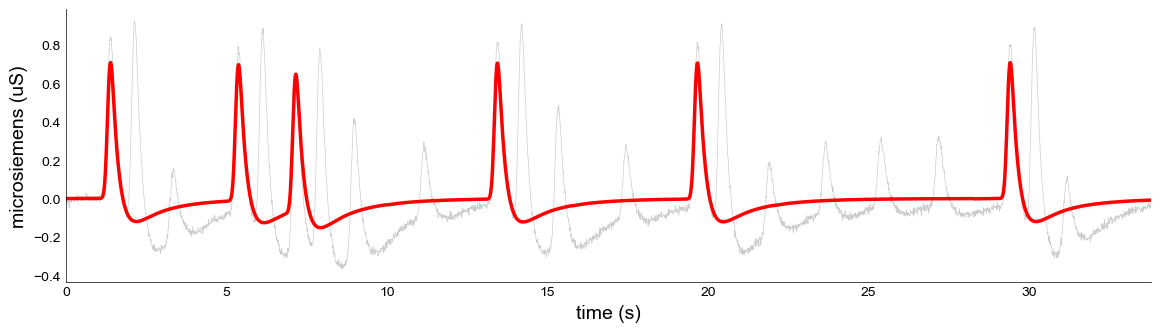

In [348]:
pl = plotting.LazyLine(
    [
        y_ds_hp,
        X_ds_hp[:,3]
    ],
    xx=np.arange(0, y_ds_hp.shape[0])/100,
    color=['#cccccc', 'r'],
    line_width=[0.5, 2.5],
    figsize=(14, 3.54),
    fontname="Arial",
    x_label="time (s)",
    y_label="microsiemens (uS)"
)

In [384]:
# fit
l1_fit = glm.fit_first_level(
    pd.DataFrame(X_ds_hp, columns=design.columns),
    y_ds_hp,
    verbose=True
)

Running GLM

=== GLM Summary ===
Data shape:              (3380, 1)
Design matrix shape:     (3380, 7)
Predictors:              ['intercept', 'CSm', 'CSm_1st_derivative', 'CSpr', 'CSpr_1st_derivative', 'CSpu', 'CSpu_1st_derivative']
Contrasts shape:         (7, 7)
Rank:                    7
Residual SSE shape:      (1,)
Betas shape:             (7, 1)
Predictions shape:       (3380, 1)
R² shape:                (1,)

Contrasts:
  Contrast 0: [0. 1. 0. 0. 0. 0. 0.]
  Contrast 1: [0. 1. 0. 0. 0. 0. 0.]
  Contrast 2: [0. 1. 0. 0. 0. 0. 0.]
  Contrast 3: [0. 1. 0. 0. 0. 0. 0.]
  Contrast 4: [0. 1. 0. 0. 0. 0. 0.]
  Contrast 5: [0. 1. 0. 0. 0. 0. 0.]
  Contrast 6: [0. 1. 0. 0. 0. 0. 0.]

T-statistics:
  t-stat 0: [16.59455019]
  t-stat 1: [16.59455019]
  t-stat 2: [16.59455019]
  t-stat 3: [16.59455019]
  t-stat 4: [16.59455019]
  t-stat 5: [16.59455019]
  t-stat 6: [16.59455019]



In [342]:
[round(i, 3) for i in l1_fit['betas'].squeeze()]

[np.float64(0.0),
 np.float64(0.371),
 np.float64(-0.008),
 np.float64(0.936),
 np.float64(-0.04),
 np.float64(0.75),
 np.float64(-0.034)]

In [337]:
full_pred = l1_fit['x_conv']@l1_fit['betas']
predictions = glm.get_event_predictions(
    events=list(dict_regr_conv.keys()), 
    X=l1_fit['x_conv'],
    betas=l1_fit['betas'],
    ev_names=list(design.columns),
)

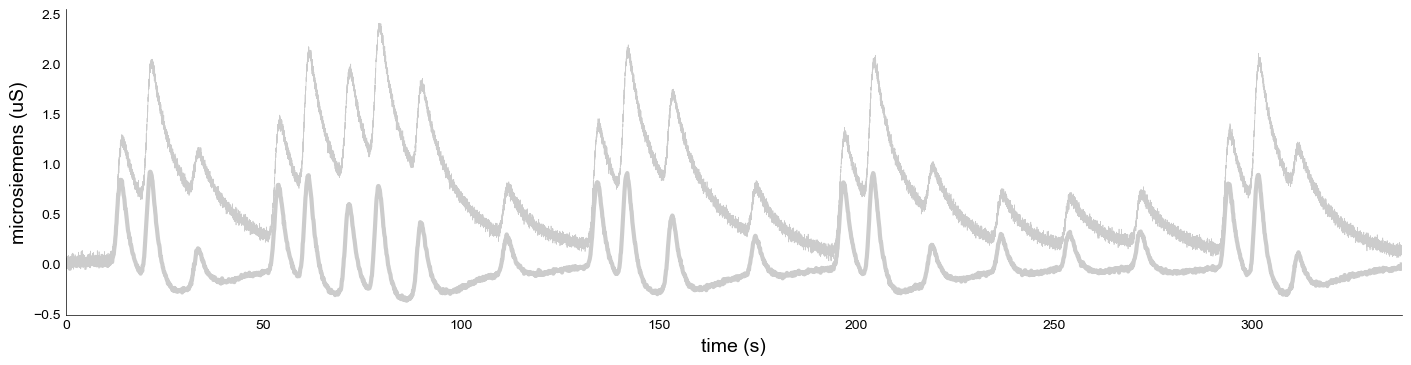

In [374]:
fig, axs = plt.subplots(figsize=(14, 3.54), constrained_layout=True)

pl = plotting.LazyLine(
    df_physio['scr'].to_numpy(),
    xx=df_physio['timestamp'].to_numpy(),
    color='#cccccc',
    line_width=0.5,
    axs=axs,
    fontname="Arial",
    x_label="time (s)",
    y_label="microsiemens (uS)",
    # save_as=r'C:\Users\Bach\Downloads\tcs.svg'
)

pl = plotting.LazyLine(
    y_ds_hp,
    xx=np.arange(0, y_ds_hp.shape[0])/10,
    color='#cccccc',
    line_width=3,
    axs=axs,
    fontname="Arial",
    x_label="time (s)",
    y_label="microsiemens (uS)",
    save_as=r'C:\Users\Bach\Downloads\filtered.svg'
)


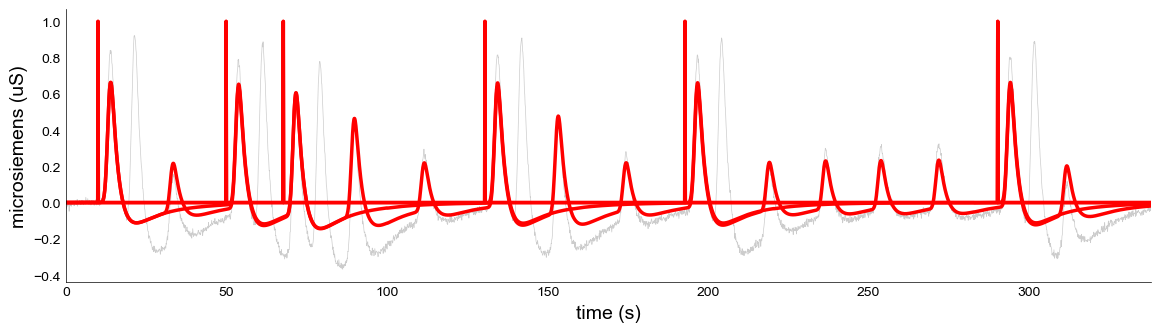

In [383]:
pl = plotting.LazyLine(
    [
        y_ds_hp,
        dict_regr_ds['CSpr'],
        dict_regr_ds['CSpr'],
        predictions['CSpr'],
        full_pred.squeeze(),
    ],
    xx=np.arange(0, y_ds_hp.shape[0])/10,
    color=['#cccccc', 'r', 'r', 'r', 'r'],
    line_width=[0.5, 2.5, 2.5, 2.5, 2.5],
    figsize=(14, 3.54),
    fontname="Arial",
    x_label="time (s)",
    y_label="microsiemens (uS)",
    save_as=r'C:\Users\Bach\Downloads\tcs.svg'
)

In [355]:
rfs = glm.get_event_predictions(
    events=list(dict_regr_conv.keys()),
    X=bs,
    betas=l1_fit["betas"],
    ev_names=list(design.columns),
    rf_mode=True,
    include_intercept=False,

)

rfs.keys()


dict_keys(['CSm', 'CSpr', 'CSpu'])

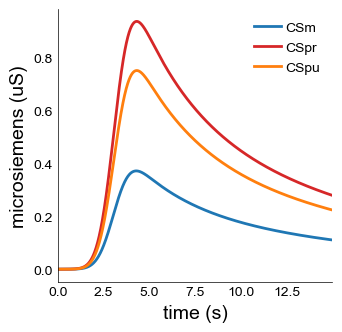

In [356]:
import numpy as np
from calinet.config import stim_colors

events = list(rfs.keys())
colors = [stim_colors[i] for i in events]
pl = plotting.LazyLine(
    [val[:1500] for _, val in rfs.items()],
    xx=(np.arange(0, bs.shape[0])/100)[:1500],
    line_width=2,
    figsize=(3.54, 3.54),
    labels=list(rfs.keys()),
    color=colors,
    fontname="Arial",
    x_label="time (s)",
    y_label="microsiemens (uS)",
    save_as=r'C:\Users\Bach\Downloads\01_rfs_scaled.svg'
)